In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [2]:
df.to_csv("marketing_campaign_cleaned.csv", index=False)

In [3]:
segmentation_df = df[['Income','TotalSpend']]

KeyError: "['TotalSpend'] not in index"

In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [5]:
import pandas as pd

df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [6]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [7]:
df['Age'] = 2025 - df['Year_Birth']

In [8]:
df['TotalSpend'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

In [9]:
df[['Income','Age','TotalSpend']].head()

,Income,Age,TotalSpend
0,58138.0,68,1617
1,46344.0,71,27
2,71613.0,60,776
3,26646.0,41,53
4,58293.0,44,422


In [10]:
segmentation_df = df[['Income','TotalSpend']]

In [11]:
from sklearn.cluster import KMeans

In [12]:
segmentation_df = df[['Income','TotalSpend']]

In [13]:
segmentation_df.head()

,Income,TotalSpend
0,58138.0,1617
1,46344.0,27
2,71613.0,776
3,26646.0,53
4,58293.0,422


In [14]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(segmentation_df)

    wcss.append(kmeans.inertia_)

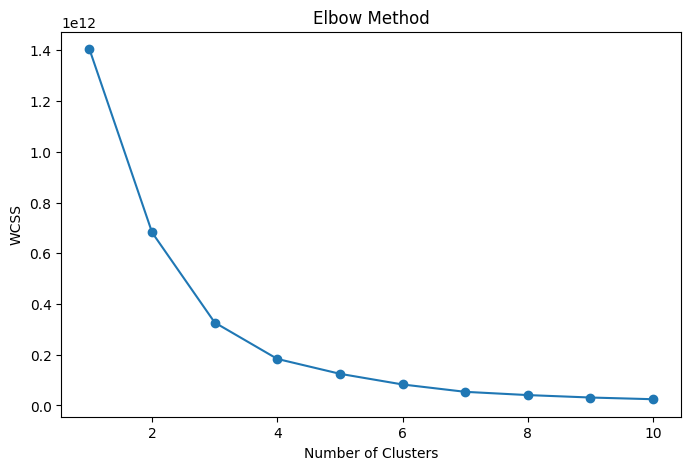

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    segmentation_df
)

In [17]:
df['Cluster'].value_counts()

Cluster
0    1167
2    1072
1       1
Name: count, dtype: int64

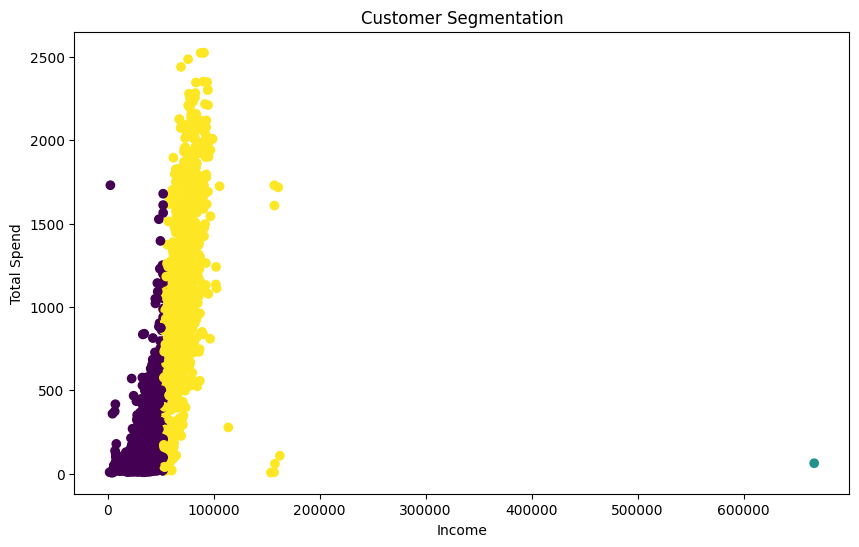

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['Income'],
    df['TotalSpend'],
    c=df['Cluster']
)

plt.title('Customer Segmentation')
plt.xlabel('Income')
plt.ylabel('Total Spend')

plt.show()

In [19]:
df.groupby('Cluster')[['Income','TotalSpend']].mean()

,Income,TotalSpend
Cluster,,
0,35032.418194,173.944302
1,666666.000000,62.000000
2,70414.500933,1076.430037


In [20]:
df['Cluster'].value_counts()

Cluster
0    1167
2    1072
1       1
Name: count, dtype: int64

In [21]:
df[df['Cluster'] == 1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpend,Cluster
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,0,0,0,0,3,11,0,48,62,1


In [22]:
df['Income'].describe()

count      2240.000000
mean      52247.251354
std       25037.797168
min        1730.000000
25%       35538.750000
50%       51741.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

In [23]:
df_no_outlier['Cluster'].value_counts()

NameError: name 'df_no_outlier' is not defined

In [24]:
df_no_outlier = df[df['Income'] < 200000]

In [25]:
df_no_outlier.shape

(2239, 32)

In [26]:
segmentation_df = df_no_outlier[['Income','TotalSpend']]

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_no_outlier['Cluster'] = kmeans.fit_predict(
    segmentation_df
)

In [28]:
df_no_outlier['Cluster'].value_counts()

Cluster
2    809
0    743
1    687
Name: count, dtype: int64

In [29]:
df_no_outlier.groupby('Cluster')[['Income','TotalSpend']].mean()

,Income,TotalSpend
Cluster,,
0,28380.375505,94.989233
1,76967.844250,1283.719068
2,52414.893736,499.918418


In [30]:
df_no_outlier['Cluster'].value_counts()

Cluster
2    809
0    743
1    687
Name: count, dtype: int64

In [31]:
df_no_outlier.groupby('Cluster')[['Income','TotalSpend']].mean()

,Income,TotalSpend
Cluster,,
0,28380.375505,94.989233
1,76967.844250,1283.719068
2,52414.893736,499.918418


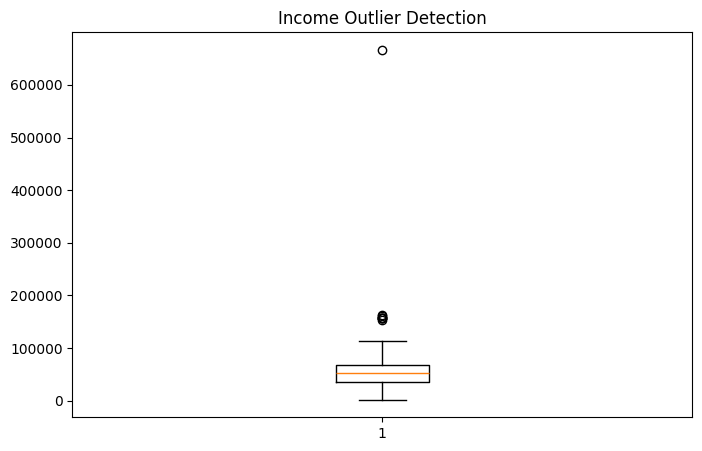

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df['Income'])

plt.title('Income Outlier Detection')

plt.show()

In [33]:
#Boxplot analysis revealed an extreme income outlier (Income = 666,666), significantly higher than the 75th percentile income (68,290). The outlier created a standalone cluster during K-Means segmentation and was removed to improve clustering quality.

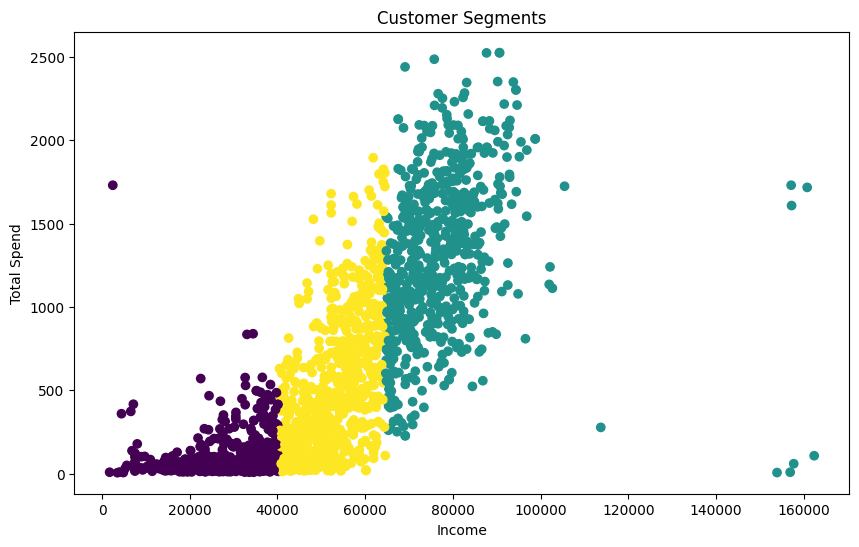

In [34]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_no_outlier['Income'],
    df_no_outlier['TotalSpend'],
    c=df_no_outlier['Cluster']
)

plt.title('Customer Segments')
plt.xlabel('Income')
plt.ylabel('Total Spend')

plt.show()

In [35]:
#Three distinct customer groups were identified based on income and spending behavior.

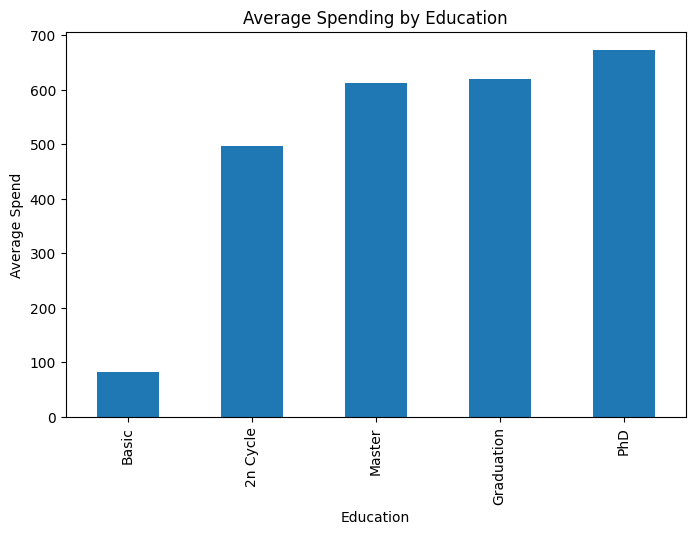

In [36]:
education_spend = df.groupby('Education')['TotalSpend'].mean()

education_spend.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Spending by Education')
plt.ylabel('Average Spend')

plt.show()

In [37]:
#Customers with higher educational qualifications generally exhibited higher spending patterns.

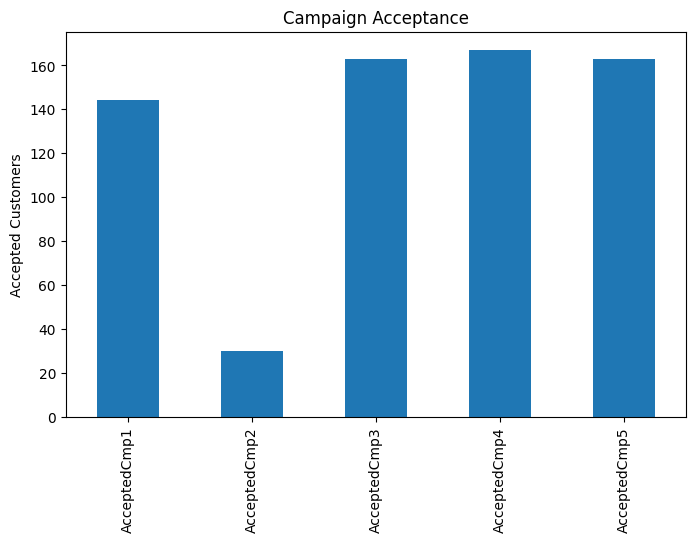

In [38]:
campaigns = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

df[campaigns].sum().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Campaign Acceptance')
plt.ylabel('Accepted Customers')

plt.show()

In [39]:
#Campaign 4 achieved the highest acceptance rate among all campaigns.

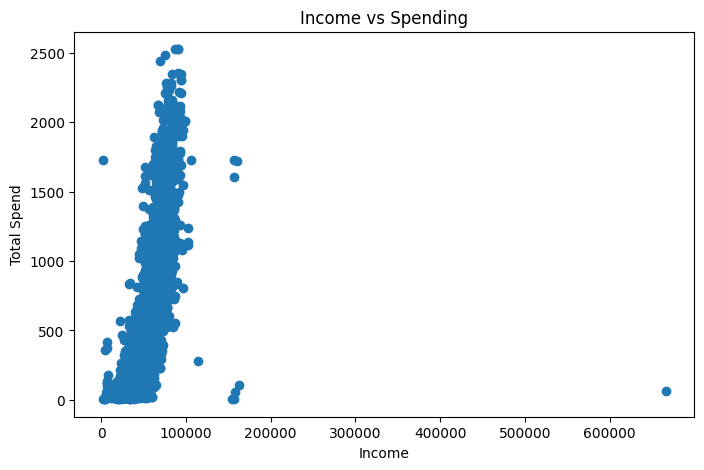

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Income'],
    df['TotalSpend']
)

plt.title('Income vs Spending')
plt.xlabel('Income')
plt.ylabel('Total Spend')

plt.show()

In [41]:
#Income and spending show a strong positive relationship (correlation = 0.66).